In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [2]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, rdMolDescriptors
from rdkit import RDLogger

#rdkit warn off
lg = RDLogger.logger()
lg.setLevel(RDLogger.CRITICAL)

# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the train and test sets from SDF files
train_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Respiratory Irritation\dataset\train_set_respiratory_irritation_features_rdkitcdk.sdf')
# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string

train_df['Morgan_Descriptors'] = train_df['Morgan_Descriptors'].apply(string_to_list)
train_df['MACCS_Descriptors'] = train_df['MACCS_Descriptors'].apply(string_to_list)

# Modred handling calc
if 'Modred_Descriptor' in train_df.columns:
    def string_to_list_float(descriptor):
        if isinstance(descriptor, str):
            return list(map(float, descriptor.strip('[]').split(',')))
        return descriptor
    train_df['Modred_Descriptor'] = train_df['Modred_Descriptor'].apply(string_to_list_float)

print("Train DataFrame:")
print(train_df.head())
print(train_df.keys())


Train DataFrame:
                                                name Outcome    ID RowID  \
0  2-[2-[3-(carboxymethyl)-4-oxo-2-sulfanylidene-...       0  1832  1832   
1                                     propyl nitrate       1   773   773   
2  dipotassium;5-[[4-anilino-6-[bis(2-hydroxyethy...       0  2998  2998   
3                                           methanol       1    42    42   
4                           nickel(2+);diperchlorate       1  1760  1760   

                                  Morgan_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0,

In [3]:
#displaying train df
train_df

train_df= train_df.sort_values(['Outcome'], ascending=True)
#train_df['RowID'] = train_df.index
train_df.head(100)

,name,Outcome,ID,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,SMILES,Molecular Weight,logP,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,2-[2-[3-(carboxymethyl)-4-oxo-2-sulfanylidene-...,0,1832,1832,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.175334414529006, 1.4122349538592949, 1.0856...",CCN1C(=CC(C)=c2sc(=C3SC(=S)N(CC(=O)O)C3=O)n(CC...,549.0156693279998,1.6916999999999993,...,2.0,3.0,3.0,0.4666666666666667,6.0,1.0,231.08,6.247927513443585,-0.3169999999999995,0.2272727272727272
1207,4-[(3-chlorophenyl)-imidazol-1-ylmethyl]benzen...,0,2528,2528,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.11254135599076372, 0.4821418511143267, 0.27...",Cl.Cl.Nc1ccc(C(c2cccc(Cl)c2)n2ccnc2)cc1N,370.05187958400006,4.182200000000003,...,2.0,0.0,0.0,0.999000000999,3.0,0.0,69.86,5.523561956057013,3.563,0.0625
1206,undecylbenzene,0,2130,2130,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.45716872860513347, -0.2711937294280377, -0...",CCCCCCCCCCCc1ccccc1,232.219100896,5.759900000000005,...,0.0,11.0,11.0,0.5,10.0,1.0,0.0,5.08746284125034,8.043999999999999,0.6470588235294118
1205,zinc;hexadecanoate;octadecanoate,0,1834,1834,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, ...","[0.40618258954786024, 0.31135923107068436, -0....",CCCCCCCCCCCCCCCC(=O)[O-].CCCCCCCCCCCCCCCCCC(=O...,602.4252527919999,9.212900000000001,...,0.0,18.0,19.0,0.999000000999,30.0,3.0,80.25999999999999,6.169925001442312,15.31600000000001,0.9411764705882352
1203,"2-chlorobenzene-1,4-diamine",0,2046,2046,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.4898168709888525, -0.29758288063011656, -0...",Nc1ccc(N)c(Cl)c1,142.029775904,1.5044000000000002,...,2.0,0.0,0.0,0.4,0.0,0.0,52.04,4.169925001442312,1.01,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2354,"propan-2-yl 2-(2,4-dichlorophenoxy)acetate",0,2006,2006,"[0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.016898926165863516, 0.12862680670911944, -...",CC(C)OC(=O)COc1ccc(Cl)cc1Cl,262.016349604,3.323800000000002,...,0.0,3.0,6.0,0.5,5.0,0.0,35.53,5.0,3.767,0.3636363636363636
1149,tetraethylplumbane,0,1882,1882,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.7760537657609485, -0.7084867309452603, -0....",C[CH2][Pb]([CH2]C)([CH2]C)[CH2]C,324.13315274,3.514800000000003,...,0.0,2.0,5.0,0.5,4.0,0.0,0.0,4.0,3.544,1.0
2355,"sodium;1,4-bis(2-ethylhexoxy)-1,4-dioxobutane-...",0,3498,3498,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5945815758915566, 0.24264785624263005, 0.45...",CCCCC(CC)COC(=O)CC(C(=O)OCC(CC)CCCC)S(=O)(=O)[...,444.215768804,0.8135000000000032,...,0.0,7.0,18.0,0.999000000999,18.0,2.0,118.18,5.754887502163469,5.040000000000001,0.9
1147,4-ethylmorpholine;4-(4-methylphenyl)-4-oxobuta...,0,3317,3317,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0673074728181708, 1.1000463160535696, 0.565...",CCN1CCOCC1.Cc1ccc(C(=O)CCC(=O)O)cc1.Cc1ccc(C(=...,499.2570025239999,4.423540000000003,...,2.0,4.0,6.0,0.999000000999,9.0,0.0,121.21,6.169925001442312,3.498,0.4285714285714285


Classes                          :  ['0' '1']
Number of cpds in each class     :  [1456, 1477]
Total number of cpds             :  2933
Class mapping:  {0: 0, 1: 1}
1    1477
0    1456
Name: Outcome, dtype: int64


{0: 0, 1: 1}

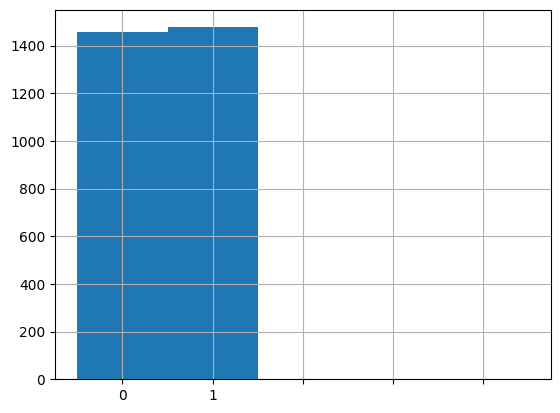

In [4]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(train_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(train_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = train_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)

#type counting and graph
print(train_df['Outcome'].value_counts())

ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info


In [5]:
#read morgan here
#morgan reading from train_df !!
y= np.int32((S))
x = np.array(list(train_df['Morgan_Descriptors']))

#displaying the x above, that we declare

print(x)

[[0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [6]:
#Random Forest
from sklearn.metrics import make_scorer, cohen_kappa_score
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# parameter
paramgrid = {
    "n_estimators": [300,400],  
    "max_features": [
        x.shape[1], x.shape[1] // 2, x.shape[1] // 4, x.shape[1] // 12,
    ],
    "max_depth": [45,50],          
    "min_samples_leaf": [1],    
    "min_samples_split": [3]    
}

# Define the cross-validator as before
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

kappa_scorer = make_scorer(cohen_kappa_score)

model_rf_morgan = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=24,
        n_jobs=-1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1
)

# Fit the model
model_rf_morgan.fit(x, y)

# Get the best model
best_model_rf_morgan = model_rf_morgan.best_estimator_

print("Best Params:", model_rf_morgan.best_params_)
print("Best Score :", model_rf_morgan.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'max_depth': 45, 'max_features': 85, 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 300}
Best Score : 0.3714644138224643


In [10]:
#Random Forest
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_rf_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_rf_morgan.predict(X_test)
    y_proba = best_model_rf_morgan.predict_proba(X_test)[:, 1]  
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[185 107]
 [ 83 212]]
Confusion Matrix for Fold 2:
[[187 104]
 [ 80 216]]
Confusion Matrix for Fold 3:
[[190 101]
 [ 77 219]]
Confusion Matrix for Fold 4:
[[173 118]
 [ 88 207]]
Confusion Matrix for Fold 5:
[[192  99]
 [ 94 201]]
Overall CV Accuracy: 0.6757475681867074
Overall CV AUC: 0.7303940404479985
Overall CV Precision: 0.6661749758861829
Overall CV Recall (Sensitivity): 0.7142579019697664
Overall CV F1 Score: 0.6892527191701425
Overall CV Specificity: 0.6366779645059549
Overall CV PPV (Positive Predictive Value): 0.6661749758861829
Overall CV NPV (Negative Predictive Value): 0.687289489312019
Overall CV CCR (Correct Classification Rate): 0.6754679332378606


In [7]:
# SVM 
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
     "C": [1,2,10],  # Regularization parameter
     "kernel": ['rbf'],  # Type of the kernel
     "gamma": ['scale', 'auto']  # Kernel coefficient
}

# 5-fold stratified shuffle split
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen’s Kappa 
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights="quadratic"
)

# GridSearchCV
model_svm_morgan = GridSearchCV(
    estimator=SVC(probability=True,class_weight="balanced",random_state=24),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    refit=True,
    verbose=1,
    n_jobs=-1
)

model_svm_morgan.fit(x, y)
best_model_svm_morgan = model_svm_morgan.best_estimator_

print("Best Params:", model_svm_morgan.best_params_)
print("Best Score :", model_svm_morgan.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best Score : 0.37742737016515215


In [11]:
#SVM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np


seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_svm_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_svm_morgan.predict(X_test)
    y_proba = best_model_svm_morgan.predict_proba(X_test)[:, 1] 
    
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))  
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[177 115]
 [ 82 213]]
Confusion Matrix for Fold 2:
[[187 104]
 [ 71 225]]
Confusion Matrix for Fold 3:
[[189 102]
 [ 74 222]]
Confusion Matrix for Fold 4:
[[175 116]
 [ 79 216]]
Confusion Matrix for Fold 5:
[[197  94]
 [ 85 210]]
Overall CV Accuracy: 0.68564285340512
Overall CV AUC: 0.7349221685895442
Overall CV Precision: 0.6719715779835976
Overall CV Recall (Sensitivity): 0.7352473660100778
Overall CV F1 Score: 0.70201619678334
Overall CV Specificity: 0.6353222237913666
Overall CV PPV (Positive Predictive Value): 0.6719715779835976
Overall CV NPV (Negative Predictive Value): 0.7028786003783478
Overall CV CCR (Correct Classification Rate): 0.6852847949007222


In [8]:
# XGB 
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

paramgrid = {
    "max_depth": [5,10],          
    "n_estimators": [230,260],           
    "learning_rate": [0.01,0.02],   
    "subsample": [0.8],              
    "colsample_bytree": [0.8],  
    "reg_lambda": [2,3]            
}

# 5-fold stratified CV
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Cohen's Kappa 
kappa_scorer = make_scorer(cohen_kappa_score)

model_xgb_morgan = GridSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=24,
        n_jobs=-1
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1
)

model_xgb_morgan.fit(x, y)
best_model_xgb_morgan = model_xgb_morgan.best_estimator_

print("Best Params:", model_xgb_morgan.best_params_)
print("Best Score :", model_xgb_morgan.best_score_)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.02, 'max_depth': 10, 'n_estimators': 260, 'reg_lambda': 3, 'subsample': 0.8}
Best Score : 0.36452199966967036


In [12]:
#XGB
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    # Split data
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit the model
    best_model_xgb_morgan.fit(X_train, y_train)
    
    # Predictions and predicted probabilities
    y_pred = best_model_xgb_morgan.predict(X_test)
    y_proba = best_model_xgb_morgan.predict_proba(X_test)[:, 1]  
    # Metrics calculation
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba)) 
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity and Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV and NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Displaying the results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[184 108]
 [ 83 212]]
Confusion Matrix for Fold 2:
[[185 106]
 [ 75 221]]
Confusion Matrix for Fold 3:
[[181 110]
 [ 72 224]]
Confusion Matrix for Fold 4:
[[171 120]
 [ 85 210]]
Confusion Matrix for Fold 5:
[[200  91]
 [ 94 201]]
Overall CV Accuracy: 0.6781378095365456
Overall CV AUC: 0.7318167050431358
Overall CV Precision: 0.6667438923950402
Overall CV Recall (Sensitivity): 0.7230485570316079
Overall CV F1 Score: 0.6933700941064527
Overall CV Specificity: 0.632556606882267
Overall CV PPV (Positive Predictive Value): 0.6667438923950402
Overall CV NPV (Negative Predictive Value): 0.6928665833847741
Overall CV CCR (Correct Classification Rate): 0.6778025819569373


In [13]:
#Neural Network 
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid
paramgrid_nn = {
    "hidden_layer_sizes": [(60,120), (300,500,800),(256,512,1024)],  
    "activation": ['relu'],             
    "solver": ['adam'],              
    "alpha": [0.0001,0.0003]                        
}

cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=24)

kappa_scorer = make_scorer(cohen_kappa_score, weights='quadratic')

model_nn_morgan = GridSearchCV(
    estimator=MLPClassifier(max_iter=1000, random_state=42),
    param_grid=paramgrid_nn,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=-1
)

# Fit the model
model_nn_morgan.fit(x, y)
best_model_nn_morgan = model_nn_morgan.best_estimator_

print("Best Params:", model_nn_morgan.best_params_)
print("Best Score :", model_nn_morgan.best_score_)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Params: {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (300, 500, 800), 'solver': 'adam'}
Best Score : 0.2524055204812602


In [14]:
#Neural Network NN
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score, f1_score
import numpy as np

seed = 42
np.random.seed(seed)

# Number of splits for cross-validation
n_splits = 5

# Prepare cross-validation
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Lists to store results for various metrics
accuracies = []
auc_scores = []
precisions = []
recalls = []
f1_scores = []
specificities = []
sensitivity_scores = []
ppvs = []
npvs = []
ccrs = []
confusion_matrices = []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model
    best_model_nn_morgan.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_nn_morgan.predict(X_test)
    y_proba = best_model_nn_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[168 124]
 [ 95 200]]
Confusion Matrix for Fold 2:
[[175 116]
 [ 94 202]]
Confusion Matrix for Fold 3:
[[174 117]
 [ 92 204]]
Confusion Matrix for Fold 4:
[[165 126]
 [108 187]]
Confusion Matrix for Fold 5:
[[184 107]
 [100 195]]
Overall CV Accuracy: 0.6321115639771848
Overall CV AUC: 0.6667140325969575
Overall CV Precision: 0.6262315097580631
Overall CV Recall (Sensitivity): 0.668900595510765
Overall CV F1 Score: 0.6467692204549534
Overall CV Specificity: 0.5947935790613378
Overall CV PPV (Positive Predictive Value): 0.6262315097580631
Overall CV NPV (Negative Predictive Value): 0.6391518314929905
Overall CV CCR (Correct Classification Rate): 0.6318470872860514


In [9]:
# LGBM 
from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import make_scorer, cohen_kappa_score

# Parameter grid 
paramgrid = {
    "n_estimators": [200,230],
    "learning_rate": [0.005,0.1],
    "max_depth": [12,15],
    "num_leaves": [26],
    "min_child_samples": [20],
    "feature_fraction": [0.7],
    "bagging_fraction": [0.7],
    "bagging_freq": [1]
}

# Cross-validator 
cv = StratifiedShuffleSplit(
    n_splits=5,
    test_size=0.2,
    random_state=24
)

# Scoring function
kappa_scorer = make_scorer(
    cohen_kappa_score,
    weights='quadratic'
)

# GridSearchCV
model_lgbm_morgan = GridSearchCV(
    estimator=LGBMClassifier(
        objective="binary",
        class_weight="balanced",
        verbosity=-1,
        force_row_wise=True,
        random_state=24
    ),
    param_grid=paramgrid,
    scoring=kappa_scorer,
    cv=cv,
    verbose=1,
    n_jobs=1
)

# fit model
model_lgbm_morgan.fit(x, y)
best_model_lgbm_morgan = model_lgbm_morgan.best_estimator_

print("Best Params:", model_lgbm_morgan.best_params_)
print("Best Score :", model_lgbm_morgan.best_score_)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Params: {'bagging_fraction': 0.7, 'bagging_freq': 1, 'feature_fraction': 0.7, 'learning_rate': 0.1, 'max_depth': 12, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 26}
Best Score : 0.3516082805972149


In [15]:
# Evaluasi LGBM
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    precision_score, recall_score, f1_score
)
import numpy as np

seed = 42
np.random.seed(seed)

# Cross-validation setup
n_splits = 5
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)

# Inisialisasi list metrik
accuracies, auc_scores, precisions, recalls, f1_scores = [], [], [], [], []
specificities, sensitivity_scores, ppvs, npvs, ccrs, confusion_matrices = [], [], [], [], [], []

def calculate_ccr(sensitivity, specificity):
    return (sensitivity + specificity) / 2

# Cross-validation loop
for train_index, test_index in cv.split(x, y):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Fit model 
    best_model_lgbm_morgan.fit(X_train, y_train)
    
    # Predictions
    y_pred = best_model_lgbm_morgan.predict(X_test)
    y_proba = best_model_lgbm_morgan.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracies.append(accuracy_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_proba))
    precisions.append(precision_score(y_test, y_pred, zero_division=0))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    confusion_matrices.append(cm)
    
    # Sensitivity & Specificity
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    sensitivity_scores.append(sensitivity)
    specificities.append(specificity)
    
    # PPV & NPV
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    ppvs.append(ppv)
    npvs.append(npv)
    
    # CCR
    ccr = calculate_ccr(sensitivity, specificity)
    ccrs.append(ccr)

# Display Results
for i, cm in enumerate(confusion_matrices):
    print(f"Confusion Matrix for Fold {i+1}:")
    print(cm)
    
print(f'Overall CV Accuracy: {np.mean(accuracies)}')
print(f'Overall CV AUC: {np.mean(auc_scores)}')
print(f'Overall CV Precision: {np.mean(precisions)}')
print(f'Overall CV Recall (Sensitivity): {np.mean(sensitivity_scores)}')
print(f'Overall CV F1 Score: {np.mean(f1_scores)}')
print(f'Overall CV Specificity: {np.mean(specificities)}')
print(f'Overall CV PPV (Positive Predictive Value): {np.mean(ppvs)}')
print(f'Overall CV NPV (Negative Predictive Value): {np.mean(npvs)}')
print(f'Overall CV CCR (Correct Classification Rate): {np.mean(ccrs)}')


Confusion Matrix for Fold 1:
[[171 121]
 [ 83 212]]
Confusion Matrix for Fold 2:
[[180 111]
 [ 78 218]]
Confusion Matrix for Fold 3:
[[173 118]
 [ 85 211]]
Confusion Matrix for Fold 4:
[[176 115]
 [ 84 211]]
Confusion Matrix for Fold 5:
[[191 100]
 [ 93 202]]
Overall CV Accuracy: 0.6631451645725648
Overall CV AUC: 0.7127835599273369
Overall CV Precision: 0.6513402880813806
Overall CV Recall (Sensitivity): 0.7135936784241869
Overall CV F1 Score: 0.6808450535846922
Overall CV Specificity: 0.6119686484959751
Overall CV PPV (Positive Predictive Value): 0.6513402880813806
Overall CV NPV (Negative Predictive Value): 0.6781807377821882
Overall CV CCR (Correct Classification Rate): 0.6627811634600811


In [1]:
import joblib

base_path = r"C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Respiratory Irritation\model\fingerprint descriptor model"

joblib.dump(
    best_model_rf_morgan,
    fr"{base_path}\Model_Respiratory_RF_morgan.pkl",
    compress=9
)

joblib.dump(
    best_model_svm_morgan,
    fr"{base_path}\Model_Respiratory_SVM_morgan.pkl",
    compress=9
)

joblib.dump(
    best_model_xgb_morgan,
    fr"{base_path}\Model_Respiratory_XGB_morgan.pkl",
    compress=9
)

joblib.dump(
    best_model_nn_morgan,
    fr"{base_path}\Model_Respiratory_NN_morgan.pkl",
    compress=9
)

joblib.dump(
    best_model_lgbm_morgan,
    fr"{base_path}\Model_Respiratory_LGBM_morgan.pkl",
    compress=9
)




SyntaxError: invalid syntax (2334756080.py, line 35)